Import Library & Load Dataset


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style untuk visualisasi agar persis seperti di jurnal
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. LOAD DATASET ASLI MASTER
# Silakan ganti 'dataset_smartphone.csv' dengan nama file Master yang sebenarnya
df = pd.read_csv(r'E:\Python - Project\phone-addiction-detection\Data\user_behavior_dataset.csv')

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
print(f"Total data: {df.shape[0]} baris dan {df.shape[1]} kolom.")
display(df.head())

Total data: 700 baris dan 11 kolom.


,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


EDA - Distribusi Umur

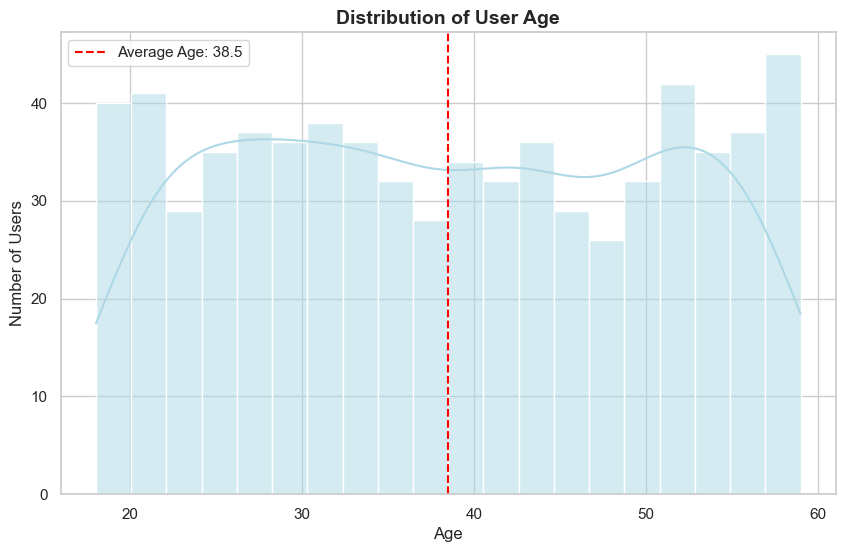

In [3]:
# 2. EDA: Distribusi Umur Pengguna (User Age Distribution)
plt.figure(figsize=(10, 6))

# Membuat histogram dengan garis distribusi (KDE)
sns.histplot(df['Age'], bins=20, kde=True, color='lightblue', edgecolor='white')

# Menambahkan garis putus-putus untuk rata-rata umur
avg_age = df['Age'].mean()
plt.axvline(avg_age, color='red', linestyle='--', label=f'Average Age: {avg_age:.1f}')

plt.title('Distribution of User Age', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.legend()
plt.show()

EDA - Analisis Tren Penggunaan (5 Histogram)

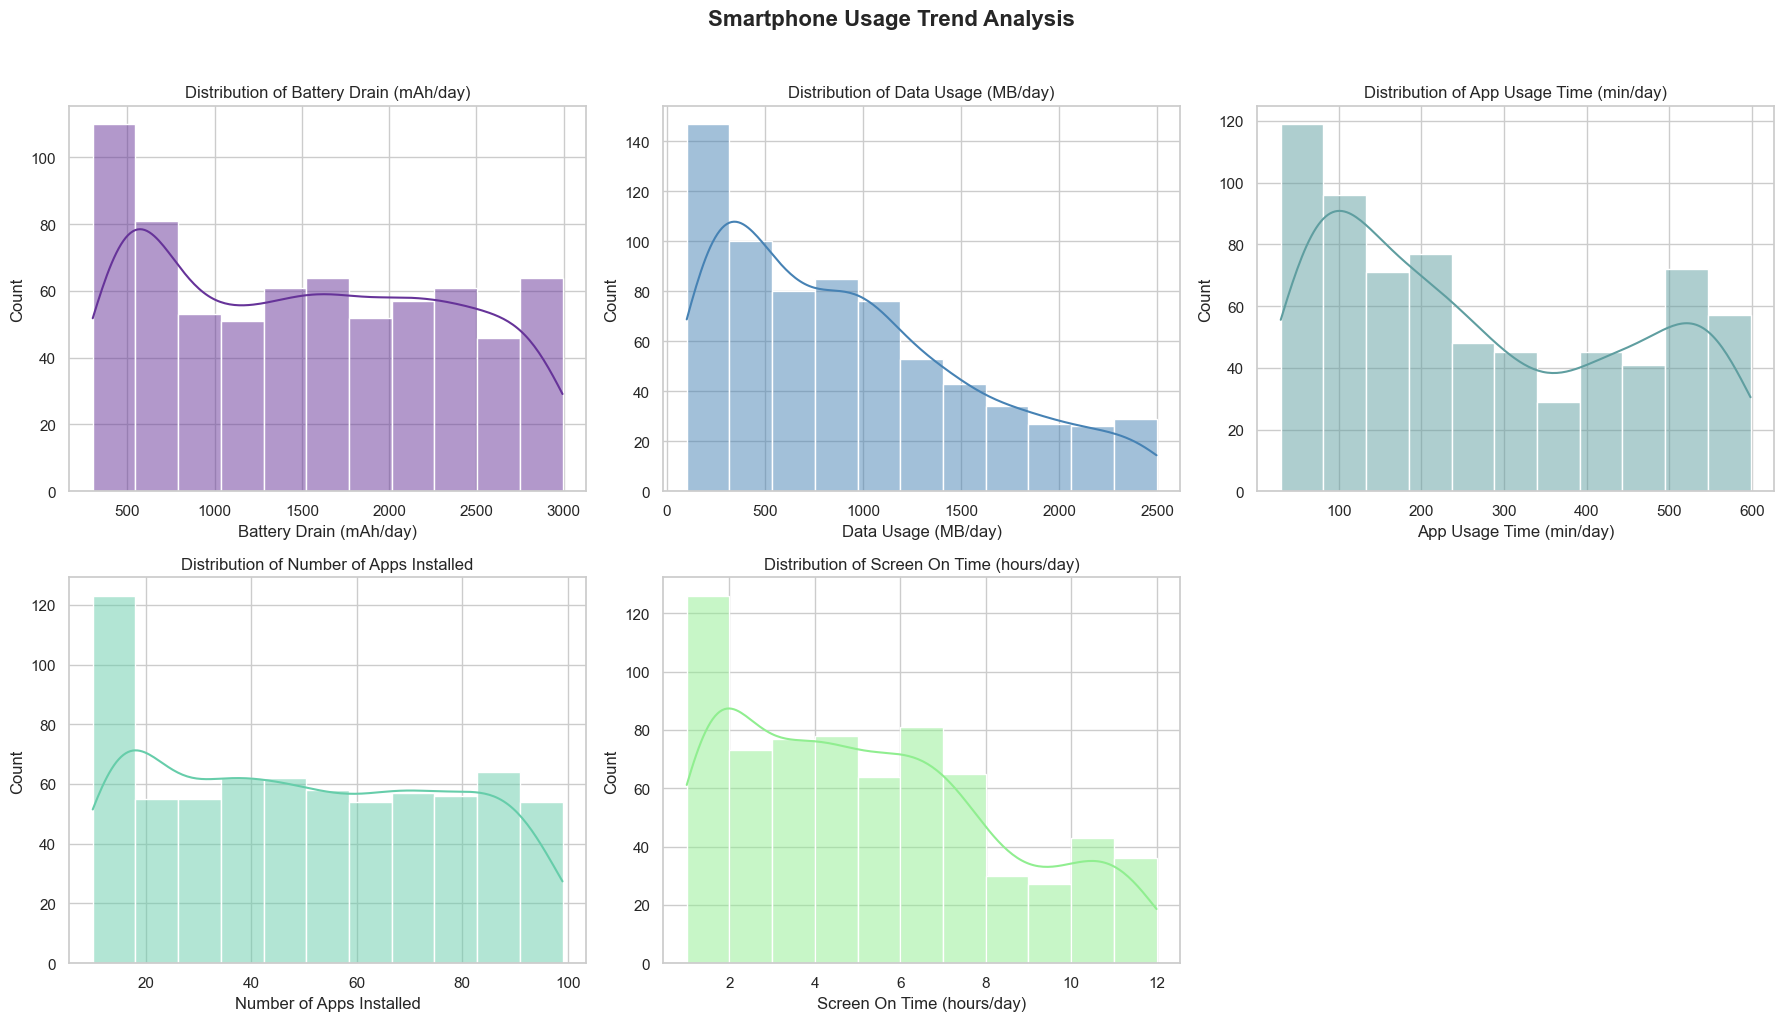

In [4]:
# 3. EDA: Analisis Tren Penggunaan Smartphone (Trend Analysis)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Smartphone Usage Trend Analysis', fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Battery Drain
sns.histplot(df['Battery Drain (mAh/day)'], kde=True, color='rebeccapurple', ax=axes[0,0])
axes[0,0].set_title('Distribution of Battery Drain (mAh/day)')

# Plot 2: Data Usage
sns.histplot(df['Data Usage (MB/day)'], kde=True, color='steelblue', ax=axes[0,1])
axes[0,1].set_title('Distribution of Data Usage (MB/day)')

# Plot 3: App Usage Time
sns.histplot(df['App Usage Time (min/day)'], kde=True, color='cadetblue', ax=axes[0,2])
axes[0,2].set_title('Distribution of App Usage Time (min/day)')

# Plot 4: Number of Apps Installed
sns.histplot(df['Number of Apps Installed'], kde=True, color='mediumaquamarine', ax=axes[1,0])
axes[1,0].set_title('Distribution of Number of Apps Installed')

# Plot 5: Screen On Time
sns.histplot(df['Screen On Time (hours/day)'], kde=True, color='lightgreen', ax=axes[1,1])
axes[1,1].set_title('Distribution of Screen On Time (hours/day)')

# Menghapus slot subplot yang kosong di sudut kanan bawah
fig.delaxes(axes[1,2])

plt.tight_layout()
plt.show()

EDA - Matriks Korelasi

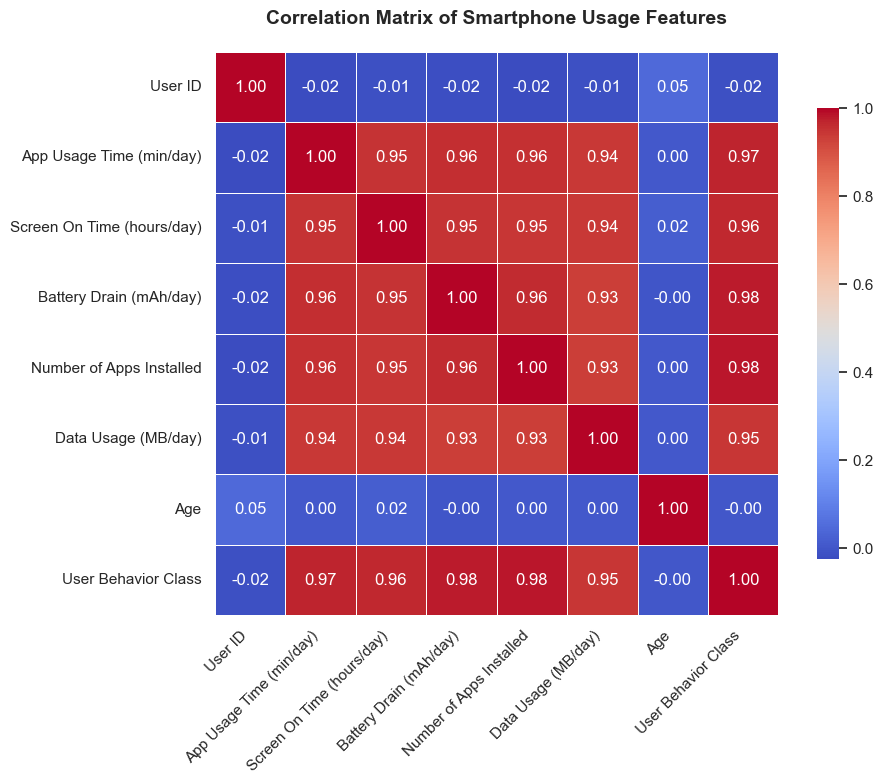

In [5]:
# 4. EDA: Matriks Korelasi antar Fitur (Correlation Matrix)
plt.figure(figsize=(10, 8))

# Memilih hanya kolom numerik agar tidak error saat menghitung korelasi
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Membuat Heatmap
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            square=True, 
            linewidths=0.5, 
            cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of Smartphone Usage Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()